In [94]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('../asteroids_2025_flat.csv')

In [17]:
df.head()

,close_approach_date,id,neo_reference_id,name,designation,nasa_jpl_url,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,estimated_diameter_min_m,...,perihelion_distance,perihelion_argument,aphelion_distance,perihelion_time,mean_anomaly,mean_motion,equinox,orbit_class_type,orbit_class_description,orbit_class_range
0,2025-01-07,2226514,2226514,226514 (2003 UX34),NaN,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,20.16,0.246919,0.552128,246.919266,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-07,2438017,2438017,438017 (2003 YO3),NaN,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,18.54,0.520661,1.164233,520.660914,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-07,2481442,2481442,481442 (2006 WO3),NaN,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,21.58,0.128397,0.287104,128.397030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-07,3485806,3485806,(2010 AL60),NaN,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,22.29,0.092588,0.207033,92.588058,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-07,3723888,3723888,(2015 NU2),NaN,https://ssd.jpl.nasa.gov/tools/sbdb_lookup.htm...,20.91,0.174805,0.390877,174.805453,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6101 entries, 0 to 6100
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   close_approach_date                6101 non-null   object 
 1   id                                 6101 non-null   int64  
 2   neo_reference_id                   6101 non-null   int64  
 3   name                               6101 non-null   object 
 4   designation                        0 non-null      float64
 5   nasa_jpl_url                       6101 non-null   object 
 6   absolute_magnitude_h               6101 non-null   float64
 7   estimated_diameter_min_km          6101 non-null   float64
 8   estimated_diameter_max_km          6101 non-null   float64
 9   estimated_diameter_min_m           6101 non-null   float64
 10  estimated_diameter_max_m           6101 non-null   float64
 11  estimated_diameter_min_miles       6101 non-null   float

In [19]:
df.drop(columns=["nasa_jpl_url", "designation", "id", "neo_reference_id", "name", "orbiting_body", "close_approach_date_full", "close_approach_date"], inplace=True)


In [20]:
# Check null percentages for ALL variables
null_percentages = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_percentages)

ascending_node_longitude             100.0
orbital_period                       100.0
perihelion_distance                  100.0
jupiter_tisserand_invariant          100.0
orbit_determination_date             100.0
first_observation_date               100.0
last_observation_date                100.0
data_arc_in_days                     100.0
observations_used                    100.0
orbit_uncertainty                    100.0
minimum_orbit_intersection           100.0
orbit_id                             100.0
aphelion_distance                    100.0
perihelion_time                      100.0
mean_anomaly                         100.0
mean_motion                          100.0
equinox                              100.0
orbit_class_type                     100.0
orbit_class_description              100.0
perihelion_argument                  100.0
orbit_class_range                    100.0
semi_major_axis                      100.0
eccentricity                         100.0
epoch_oscul

In [21]:
df.drop(columns=["estimated_diameter_min_m", "estimated_diameter_max_m", "estimated_diameter_min_miles", "estimated_diameter_max_miles", "estimated_diameter_min_feet", "estimated_diameter_max_feet", "relative_velocity_km_per_hour", "relative_velocity_miles_per_hour", "miss_distance_astronomical", "miss_distance_lunar", "miss_distance_miles"], inplace=True)

In [22]:
df.dropna(axis=1, inplace=True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6101 entries, 0 to 6100
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   absolute_magnitude_h               6101 non-null   float64
 1   estimated_diameter_min_km          6101 non-null   float64
 2   estimated_diameter_max_km          6101 non-null   float64
 3   is_potentially_hazardous_asteroid  6101 non-null   bool   
 4   is_sentry_object                   6101 non-null   bool   
 5   epoch_date_close_approach          6101 non-null   int64  
 6   relative_velocity_km_per_sec       6101 non-null   float64
 7   miss_distance_kilometers           6101 non-null   float64
dtypes: bool(2), float64(5), int64(1)
memory usage: 298.0 KB


In [24]:
df.head()

,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,is_potentially_hazardous_asteroid,is_sentry_object,epoch_date_close_approach,relative_velocity_km_per_sec,miss_distance_kilometers
0,20.16,0.246919,0.552128,True,False,1736208480000,16.548994,1.849152e+07
1,18.54,0.520661,1.164233,False,False,1736238240000,15.276752,1.213633e+07
2,21.58,0.128397,0.287104,False,False,1736238060000,21.648876,5.823974e+07
3,22.29,0.092588,0.207033,False,False,1736236080000,8.989291,9.414482e+06
4,20.91,0.174805,0.390877,True,False,1736290080000,19.133631,7.346700e+07


In [25]:
df.shape

(6101, 8)

In [26]:
df.to_csv("asteroids_cleaned.csv", index=False)


In [27]:
df = pd.read_csv('asteroids_cleaned.csv')

## **Visuals**

In [96]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Times New Roman'],
    'font.size': 12,              
    'axes.titlesize': 20,       
    'axes.labelsize': 14,  
    'axes.labelcolor': 'darkgrey',      
})

In [65]:
df['miss_distance_kilometers'].describe()

count    6.101000e+03
mean     2.517659e+07
std      2.254705e+07
min      6.599181e+03
25%      5.632062e+06
50%      1.827075e+07
75%      4.199399e+07
max      7.478989e+07
Name: miss_distance_kilometers, dtype: float64

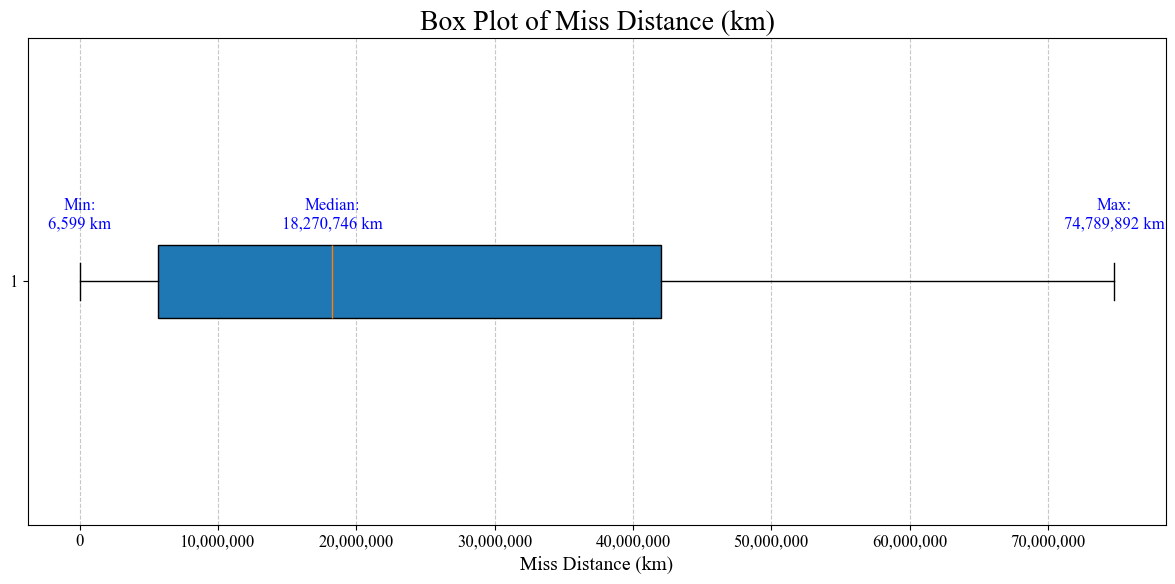

In [93]:
from matplotlib import ticker


plt.figure(figsize=(12, 6))
miss_bp = plt.boxplot(df['miss_distance_kilometers'], vert=False, patch_artist=True, whis=[0, 100])
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Box Plot of Miss Distance (kilometers)')
plt.xlabel('Miss distance (km)', rotation=0)

stats = df['miss_distance_kilometers'].describe()
vals_to_annotate = {
    'Min': stats['min'],
    'Median': stats['50%'],
    'Max': stats['max'],
}

for label, val in vals_to_annotate.items():
    plt.text(val, 1.1, f'{label}:\n{val:,.0f} km', 
             ha='center', va='bottom', color='blue')

plt.title('Box Plot of Miss Distance (km)')
plt.xlabel('Miss Distance (km)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()



## **getting data ready for training**
### predictor value = miss distance

In [29]:
X = df.drop(columns=["miss_distance_kilometers"])
y = df['miss_distance_kilometers']

In [30]:
X['is_potentially_hazardous_asteroid'] = X['is_potentially_hazardous_asteroid'].astype(int)
X['is_sentry_object'] = X['is_sentry_object'].astype(int)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)